In [1]:
from pathlib import Path
import omnipath as op
import os 


import mudata as mu
import scanpy as sc


# seting global dir
cwd=Path.cwd()
if cwd.parent.name == "notebooks":
    os.chdir(cwd.parent.parent) 
print(os.getcwd())

# constants
PATH_DATA = Path('data/multimodal')

/home/maxi7524/micromamba/envs/OmniPhysiBoss_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/maxi7524/repositories/project_computational_biology_initial_conditions_pymyboss


# Learn Omnipath

In [ ]:
# wszystkie zasoby którymi zarządza API (część jest zbędna ??) 
op.interactions.AllInteractions.resources()

79.2kB [00:00, 135MB/s]


('ACSN',
 'ACSN_SignaLink3',
 'ARACNe-GTEx_DoRothEA',
 'ARN',
 'Adhesome',
 'AlzPathway',
 'BEL-Large-Corpus_ProtMapper',
 'Baccin2019',
 'BioGRID',
 'CA1',
 'CancerCellMap',
 'CancerDrugsDB',
 'CellCall',
 'CellChatDB',
 'CellChatDB-cofactors',
 'CellPhoneDB',
 'CellPhoneDB_Cellinker',
 'CellTalkDB',
 'Cellinker',
 'CollecTRI',
 'Cui2007',
 'CytReg_CollecTRI',
 'DEPOD',
 'DIP',
 'DLRP_Cellinker',
 'DLRP_talklr',
 'DOMINO',
 'DeathDomain',
 'DoRothEA',
 'DoRothEA-A_CollecTRI',
 'DoRothEA-reviews_DoRothEA',
 'ELM',
 'EMBRACE',
 'ENCODE-distal',
 'ENCODE-proximal',
 'ENCODE_tf-mirna',
 'ExTRI_CollecTRI',
 'FANTOM4_DoRothEA',
 'Fantom5_LRdb',
 'GEREDB_CollecTRI',
 'GOA_CollecTRI',
 'Guide2Pharma',
 'Guide2Pharma_Cellinker',
 'Guide2Pharma_LRdb',
 'Guide2Pharma_talklr',
 'HINT',
 'HOCOMOCO_DoRothEA',
 'HPMR',
 'HPMR_Cellinker',
 'HPMR_LRdb',
 'HPMR_talklr',
 'HPRD',
 'HPRD-phos',
 'HPRD_KEA',
 'HPRD_LRdb',
 'HPRD_MIMP',
 'HPRD_talklr',
 'HTRI_CollecTRI',
 'HTRIdb',
 'HTRIdb_DoRothEA',
 'Hu

In [12]:
# to jest fragmenty tylko posttransational i dają  infruacje o tym czy kuratorowane, czy bepośrednie czy stymulaje hamuje itd.l 
# UWAGA - kierunkowe biorą się z tego że jedna aktywuje drugą nieskierowana bierze się z tego, że wiążą się w jedne kompleks białkowy np/
op.interactions.PostTranslational().get(organism='human')

15.6MB [00:01, 9.92MB/s]


,source,target,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,sources,references,curation_effort,n_sources,n_primary_sources,n_references,references_stripped
0,P0DP25,P48995,True,False,True,True,False,True,TRIP,TRIP:11983166;TRIP:11290752;TRIP:12601176,3,1,1,3,11290752;11983166;12601176
1,P0DP23,P48995,True,False,True,True,False,True,TRIP,TRIP:11983166;TRIP:11290752;TRIP:12601176,3,1,1,3,11290752;11983166;12601176
2,P0DP24,P48995,True,False,True,True,False,True,TRIP,TRIP:11983166;TRIP:11290752;TRIP:12601176,3,1,1,3,11290752;11983166;12601176
3,Q03135,P48995,True,True,False,True,True,False,HINT;TRIP;DIP;IntAct;Lit-BM-17;HPRD,IntAct:19897728;TRIP:19351713;HINT:19897728;HP...,15,6,6,8,10980191;12732636;14551243;16822931;18430726;1...
4,P14416,P48995,True,True,False,True,True,False,TRIP,TRIP:18261457,1,1,1,1,18261457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139049,Q9UGJ0,Q13621,True,False,False,False,False,False,SIGNOR_ProtMapper;ProtMapper,ProtMapper:17341212,1,2,1,1,17341212
139050,P24941,O75874,True,False,False,False,False,False,SIGNOR_ProtMapper;ProtMapper,ProtMapper:34929314,1,2,1,1,34929314
139051,Q9UGJ0,P35790,True,False,False,False,False,False,SIGNOR_ProtMapper;ProtMapper,ProtMapper:34929314,1,2,1,1,34929314
139052,Q9UGJ0,P41235,True,False,False,False,False,False,SIGNOR_ProtMapper;ProtMapper,ProtMapper:12740371,1,2,1,1,12740371


In [14]:
df = op.interactions.AllInteractions.get()

37.1MB [00:02, 14.0MB/s]


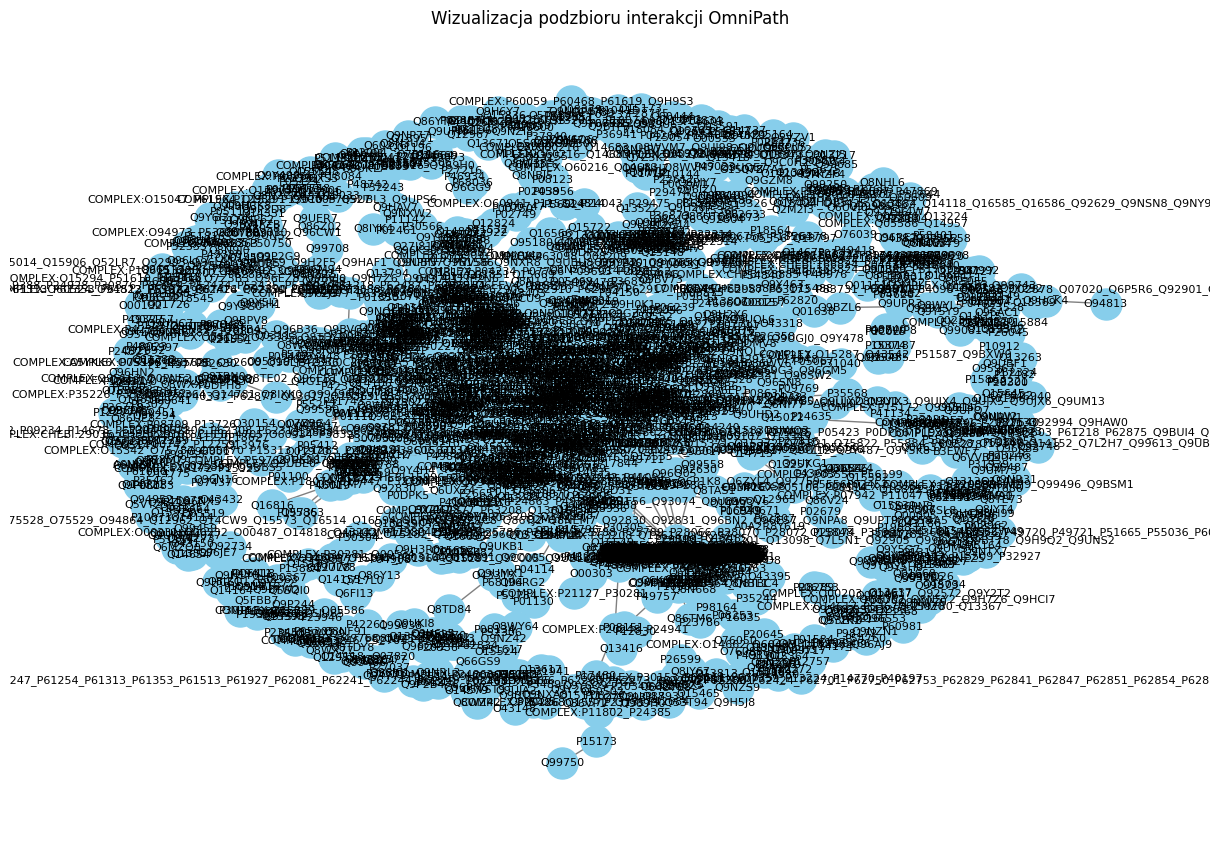

In [18]:
# Import niezbędnych bibliotek
import omnipath as op
import networkx as nx
import matplotlib.pyplot as plt

# Pobranie danych (ograniczamy liczbę, żeby graf nie był nieczytelny)
## Pobierz pierwsze 100 interakcji z bazy 

# Budowa grafu
## Konwersja DataFrame na obiekt grafu NetworkX
G = nx.from_pandas_edgelist(
    df.head(10_000), 
    source='source', 
    target='target', 
    create_using=nx.Graph()
)

# Wizualizacja
## Ustawienie układu grafu (layout)
pos = nx.spring_layout(G, seed=42)

## Rysowanie grafu
plt.figure(figsize=(12, 8))
nx.draw(
    G, pos, 
    with_labels=True, 
    node_size=500, 
    node_color='skyblue', 
    font_size=8, 
    edge_color='gray'
)
plt.title("Wizualizacja podzbioru interakcji OmniPath")
plt.show()

In [23]:
op.interactions.import_intercell_network()

,source,target,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,sources,references,type,...,category_source_intercell_target,uniprot_intercell_target,genesymbol_intercell_target,entity_type_intercell_target,consensus_score_intercell_target,transmitter_intercell_target,receiver_intercell_target,secreted_intercell_target,plasma_membrane_transmembrane_intercell_target,plasma_membrane_peripheral_intercell_target
0,P0DP25,P48995,False,True,True,False,True,TRIP,TRIP:11290752;TRIP:11983166;TRIP:12601176,post_translational,...,composite,P48995,TRPC1,protein,2,False,True,False,False,False
1,P0DP25,P48995,False,True,True,False,True,TRIP,TRIP:11290752;TRIP:11983166;TRIP:12601176,post_translational,...,resource_specific,P48995,TRPC1,protein,3,False,True,False,False,False
2,P0DP25,P48995,False,True,True,False,True,TRIP,TRIP:11290752;TRIP:11983166;TRIP:12601176,post_translational,...,composite,P48995,TRPC1,protein,3,False,True,False,False,False
3,P0DP25,P48995,False,True,True,False,True,TRIP,TRIP:11290752;TRIP:11983166;TRIP:12601176,post_translational,...,composite,P48995,TRPC1,protein,2,False,True,False,False,False
4,P0DP25,P48995,False,True,True,False,True,TRIP,TRIP:11290752;TRIP:11983166;TRIP:12601176,post_translational,...,resource_specific,P48995,TRPC1,protein,3,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115059,P01730,Q9Y490,False,False,False,False,False,ProtMapper;Sparser_ProtMapper,ProtMapper:33410333,post_translational,...,resource_specific,Q9Y490,TLN1,protein,1,False,True,False,False,False
115060,P01730,Q9Y490,False,False,False,False,False,ProtMapper;Sparser_ProtMapper,ProtMapper:33410333,post_translational,...,resource_specific,Q9Y490,TLN1,protein,1,False,True,False,False,False
115061,P25090,Q7KZI7,False,False,False,False,False,ProtMapper;Sparser_ProtMapper,ProtMapper:32471307,post_translational,...,composite,Q7KZI7,MARK2,protein,1,False,True,False,False,False
115062,P25090,Q7KZI7,False,False,False,False,False,ProtMapper;Sparser_ProtMapper,ProtMapper:32471307,post_translational,...,composite,Q7KZI7,MARK2,protein,1,False,True,False,False,False


## Library part

## Validation part

In [2]:
# ładujemy dane 
# create ann data objects
rna = sc.read(PATH_DATA / "sma_rna.h5ad") # 
msi = sc.read(PATH_DATA / "sma_msi.h5ad")
ct = sc.read(PATH_DATA / "sma_deconv.h5ad")

# create multimodal data
# raw_mdata = mu.MuData({'rna':rna, 'msi':msi, 'ct':ct})
# mdata = unify_multimodal_data(raw_mdata, modalities=['rna', 'msi', 'ct'])
raw_mdata = mu.MuData({'rna':rna, 'ct':ct})

/home/maxi7524/micromamba/envs/OmniPhysiBoss_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/maxi7524/micromamba/envs/OmniPhysiBoss_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [3]:
raw_mdata

MuData object with n_obs × n_vars = 3036 × 16534
  2 modalities
    rna:	3036 × 16486
      obs:	'in_tissue', 'array_row', 'array_col', 'x', 'y', 'lesion', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      uns:	'lesion_colors', 'log1p', 'region_colors', 'spatial'
      obsm:	'spatial'
      layers:	'counts'
    ct:	3036 × 48
      obs:	'in_tissue', 'array_row', 'array_col', 'x', 'y', 'lesion', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'uniform_density', 'rna_count_based_density'
      uns:	'lesion_colors', 'log1p', 'overlap_genes', 'region_colors', 'spatial', 'training_genes'
      obsm:	'spatial', 'tangram_ct_pred'

In [4]:
from OmniPhysiBoSS.io.mdata.mdata_pipeline import run_mdata_processing_pipeline
mdata = run_mdata_processing_pipeline(raw_mdata, modalities=['rna', 'ct'])

[-] Initiating multimodal data harmonization across omics layers...
           MULTIMODAL DATA HARMONIZATION & DATA LOSS REPORT
[-] Modality Input Size  : 'rna' contains initially 3036 cells.
[-] Modality Input Size  : 'ct' contains initially 3036 cells.
[-] Data Retention Audit Trail:
    -> Modality 'rna': Retained 3036/3036 cells (100.00%). Lost 0 cells.
    -> Modality 'ct': Retained 3036/3036 cells (100.00%). Lost 0 cells.
--------------------------------------------------------------------------------
[✓] Harmonization Complete: 3036 cells mutually shared across all layers.
--------------------------------------------------------------------------------


/home/maxi7524/micromamba/envs/OmniPhysiBoss_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/home/maxi7524/micromamba/envs/OmniPhysiBoss_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/home/maxi7524/micromamba/envs/OmniPhysiBoss_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by

[-] Linking initialized main modality 'rna' tracking maps to global root...
[✓] Linking complete

[-] Scanning spatial density distributions for modality: 'rna'...
 -> Optimal mathematical bandwidth isolated (k >= 6): 1724.1379310344828
[-] Computing spatial neighbors into modality 'rna'].obsp['spatial_connectivities']...
[-] Computing bivariate association scores via 'cosine'...


/home/maxi7524/micromamba/envs/OmniPhysiBoss_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/home/maxi7524/micromamba/envs/OmniPhysiBoss_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/home/maxi7524/micromamba/envs/OmniPhysiBoss_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_uniq

[✓] Local bivariate metrics mapped to mdata['rna'].uns['liana_res']
[-] Requesting intracellular interaction pathways from OmniPath...
[✓] Stored intracellular network under uns['intracellular_metadata_df']. Total edges: 65806
[-] Requesting comprehensive intercellular metadata network from OmniPath...
[✓] Completed metadata attachment. Stored annotated dataframe under mdata.uns['intercellular_metadata_df'].
[✓] Multi-modal processing pipeline completed successfully.


/home/maxi7524/micromamba/envs/OmniPhysiBoss_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/home/maxi7524/micromamba/envs/OmniPhysiBoss_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
